In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/2"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第2章 確率 (Probabilities)
## 2.4 確率密度の変換 (Transformation of Densities)

本ノートブックは、教科書『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』(Bishop & Bishop, 2024) の **第2章 2.4節「確率密度の変換 (Transformation of Densities)」** および **2.4.1項「多変量分布 (Multivariate distributions)」** を完全網羅し、厳密な数理導出、対話的シミュレーション、および教科書図版（Figure 2.12, Figure 2.13）の高精度な再現を提供するものです。

確率変数を非線形に変換したときの確率密度の振る舞いは、現代の深層学習において **正規化フロー (Normalizing Flows: 第18章)** や **変分オートエンコーダ (VAE)** などの深層生成モデルを支える極めて根幹的な数学原理です。

本ノートブックでは、まず1次元変数変換における確率保存則と密度の変換公式（式 2.71）を導出し、通常の関数変換との根本的な相違である **「最頻値（モード）の変数依存性」**（式 2.72 - 2.73, Figure 2.12）を数学的・幾何学的に解明します。続いて多変量空間へと拡張し、**ヤコビアン行列（ヤコビ行列）とヤコビ行列式** による局所体積変化率（式 2.76 - 2.77, Exercise 2.20）を導出します。そして、単純な2次元ガウス分布が非線形写像によって4つのピークを持つ多峰性分布へと変形する様子（Figure 2.13）を忠実に再現・可視化します。

---

### 目次
1. [2.4 確率密度の変換 (Transformation of Densities)](#sec_2_4)
   - 通常の関数変換と確率密度変換の相違
   - 微小確率質量保存則と1次元変換公式の導出 (式 2.71)
   - なぜ絶対値 $|g'(y)|$ が必須なのか？
2. [最頻値（モード）の変数依存性 (Dependence of Modes on Coordinates)](#sec_mode)
   - 通常関数の最大値の共変性 (式 2.72)
   - 確率密度の導関数と2階微分項 $g''(y)$ の出現 (式 2.73)
   - なぜ線形変換でのみモードが保存されるのか？
3. [教科書図版の完全再現: Figure 2.12](#sec_fig2_12)
   - ロジット/シグモイド変換モデルの構築 (式 2.74, 2.75)
   - $N = 50,000$ サンプルによるヒストグラムと理論密度の完全一致
   - 4本の曲線（$p_x(x)$, $g^{-1}(x)$, $p_x(g(y))$, $p_y(y)$）の描画
4. [2.4.1 多変量分布の密度変換 (Multivariate distributions)](#sec_2_4_1)
   - $D$ 次元変数変換と体積要素の歪み
   - ヤコビアン行列 $\mathbf{J}$ とヤコビ行列式 $\det \mathbf{J}$ の定義 (式 2.76, 2.77)
   - 多次元確率質量保存則 $\int p_y(\mathbf{y}) d\mathbf{y} = \int p_x(\mathbf{x}) d\mathbf{x} = 1$
5. [教科書図版の完全再現: Figure 2.13](#sec_fig2_13)
   - 2次元非線形写像モデルの定式化 (式 2.78, 2.79)
   - 下三角ヤコビアン行列と行列式の解析導出 (Exercise 2.20)
   - 中心抑制と4つのピーク（ローブ）の形成機構
   - 6パネル構成による幾何学的変形の可視化
6. [深層学習との接続: 正規化フロー (Normalizing Flows)](#sec_deep_learning)
   - 単純分布から複雑分布を生成する可逆ニューラルネットワーク
   - 三角ヤコビアンと計算量 $\mathcal{O}(D)$ の重要性 (RealNVP, MAF, Glow)
7. [まとめと理解度自己診断](#sec_summary)


In [1]:
# 環境セットアップと共通モジュールのインポート
import sys, os
sys.path.append(os.path.abspath('../'))

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, optimize

from common.plot_utils import setup_style, save_plot
from common.probability import (
    transform_density_1d,
    DensityTransformation1DExample,
    BivariateTransformation2DExample
)

setup_style()
print("環境セットアップ完了: common.probability から Section 2.4 ユーティリティを正常に読み込みました。")


環境セットアップ完了: common.probability から Section 2.4 ユーティリティを正常に読み込みました。


<a id="sec_2_4"></a>
---
### 2.4 確率密度の変換 (Transformation of Densities)

確率論および機械学習において、ある変数 $x$ から別の変数 $y$ への変換 $x = g(y)$ を考えることは極めて頻繁にあります。しかし、**確率変数の変換は、通常の決定論的関数の変換とは根本的に異なります**。

#### 通常の関数の変換 (Function Transformation)
通常の関数 $f(x)$ において、変数を $x = g(y)$ と置換した場合、新しい関数 $\tilde{f}(y)$ は単に引数を置き換えるだけで得られます：
$$\tilde{f}(y) = f(g(y))$$
このとき、ある点 $x_0 = g(y_0)$ における関数の値は変化せず、$\tilde{f}(y_0) = f(x_0)$ が成り立ちます。

#### 確率密度の変換 (Probability Density Transformation)
これに対し、確率密度 $p_x(x)$ を持つ確率変数 $x$ を考えます。変数変換 $x = g(y)$（$g$ は単調かつ可逆な関数とします）によって新しい確率変数 $y$ を定義したとき、新しい確率密度 $p_y(y)$ は単なる $p_x(g(y))$ には**なりません**。

なぜなら、確率密度そのものは確率ではなく、**区間 $[x, x + \delta x]$ における確率質量** が物理的な実体だからです。微小区間 $(x, x + \delta x)$ に入る確率は、対応する微小区間 $(y, y + \delta y)$ に入る確率と厳密に等しくなければなりません（**確率質量の保存**）：
$$p_y(y) \delta y \approx p_x(x) \delta x$$

ここで、$\delta x$ と $\delta y$ の符号について注意が必要です。関数 $g(y)$ が単調増加であれば $\delta x$ と $\delta y$ は同符号ですが、単調減少であれば $\delta y > 0$ に対して $\delta x < 0$ となります。しかし確率は常に非負（$\ge 0$）でなければならないため、微小幅の比の絶対値をとる必要があります：
$$p_y(y) |\delta y| \approx p_x(x) |\delta x|$$

両辺を $|\delta y|$ で割り、$\delta y \to 0$ の極限をとることで、Bishop (2024) の **確率密度の変数変換公式 (式 2.71)** が導かれます：

$$p_y(y) = p_x(x) \left| \frac{dx}{dy} \right| = p_x(g(y)) |g'(y)| \qquad (2.71)$$

> [!IMPORTANT]
> **ヤコビ因子の役割**
> 因子 $|g'(y)| = |dx/dy|$ は、変数変換に伴う「空間の局所的な拡大・縮小率」を表すヤコビ因子（ヤコビアン）です。
> - $g'(y) > 1$ の領域：$y$ の微小区間が $x$ 空間で引き伸ばされるため、密度の高さを補正して確率質量を保存するために $p_y(y)$ は大きくなります。
> - $g'(y) < 1$ の領域：$y$ の微小区間が $x$ 空間で圧縮されるため、$p_y(y)$ は小さくなります。


<a id="sec_mode"></a>
---
### 最頻値（モード）の変数依存性 (Dependence of Modes on Coordinates)

確率密度の変換則における最も重要かつ非自明な帰結の一つが、**「最頻値（モード: 確率密度が最大となる点）は変数の表現形式（座標系の選び方）に依存する」** という事実です。

#### 1. 通常の関数の最大値の共変性
通常の関数 $\tilde{f}(y) = f(g(y))$ の極値を調べるため、合成関数の微分法（チェインルール）を適用します：
$$\frac{d}{dy}\tilde{f}(y) = f'(g(y)) g'(y)$$
$g'(y) \neq 0$ である限り、$\frac{d}{dy}\tilde{f}(y) = 0$ となる条件は $f'(g(y)) = 0$ と完全に同値です。
したがって、もし $x$ 空間での最大値が $\hat{x}$ であれば、$y$ 空間での最大値 $\hat{y}$ は必ず以下を満たします：
$$\hat{x} = g(\hat{y}) \qquad (2.72)$$
すなわち、通常の関数の最大値の位置は、変数変換に対して **共変（covariant: 正しく変換についてくる）** です。

#### 2. 確率密度の最大値（モード）の振る舞い
一方、確率密度 $p_y(y)$ について同様の微分を行います。$g(y)$ が単調増加（$g'(y) > 0$）のとき $s = +1$、単調減少（$g'(y) < 0$）のとき $s = -1$ と置くと、$|g'(y)| = s g'(y)$ と書けます。
これを用いて式 (2.71) を微分すると、積の微分法により **Bishop (2024) の式 (2.73)** が得られます：

$$\frac{d}{dy} p_y(y) = s \frac{d}{dy} \left\{ p_x(g(y)) g'(y) \right\} = s p_x'(g(y)) \{g'(y)\}^2 + s p_x(g(y)) g''(y) \qquad (2.73)$$

この式の第2項 $s p_x(g(y)) g''(y)$ に注目してください！
- $x$ 空間のモード $\hat{x}$（すなわち $p_x'(\hat{x}) = 0$ となる点）に対応する $y = g^{-1}(\hat{x})$ を代入すると、第1項は $0$ になります。
- しかし、**第2項 $s p_x(g(y)) g''(y)$ は一般に $0$ にはなりません**（$g$ が非線形変換の場合、$g''(y) \neq 0$ であるため）。
- したがって、$p_y'(g^{-1}(\hat{x})) \neq 0$ となり、$x$ の最頻値の位置を変換した点 $g^{-1}(\hat{x})$ は、$y$ 空間での確率密度の最頻値 $\hat{y}$ とは**一致しません**！

$$\hat{x} \neq g(\hat{y}) \quad (\text{非線形変換の場合})$$

> [!NOTE]
> **線形変換の場合の特例**
> もし変換が線形（アフィン変換） $x = g(y) = ay + b$ であれば、$g''(y) = 0$ となるため第2項が消滅し、最頻値の位置は保存されます（$\hat{x} = a \hat{y} + b$）。
>
> **ベイズ推論・機械学習への深遠な示唆**
> ベイズ統計において頻繁に用いられる **事後確率最大化 (MAP: Maximum A Posteriori) 推定** は、事後分布のモード（最大値）を求める手法です。しかし上の解析から明らかなように、パラメータの表現方法（例えば分散 $\sigma^2$ でパラメータ化するか、標準偏差 $\sigma$ でパラメータ化するか、あるいは精度 $\beta = 1/\sigma^2$ でパラメータ化するか）を変えるだけで、**MAP 推定値そのものが変化してしまいます**。
> これが、現代のベイズ深層学習において単なる MAP 推定ではなく、分布全体を積分（マージナライズ）する完全なベイズ的アプローチや MCMC / 変分推論が重視される根本的理由の一つです。


In [2]:
# 1次元密度変換の数理検証: モードの移動と微分方程式 (式 2.73) の確認
example_1d = DensityTransformation1DExample(mu=6.5, sigma=1.0)

# 1. 各種モードの計算
mode_x = example_1d.mode_x()
mode_func = example_1d.mode_function_transform()
mode_density = example_1d.mode_py()

print("=" * 60)
print(f"x 空間のモード (mu):                       {mode_x:.4f}")
print(f"単純関数変換 px(g(y)) のモード g^{{-1}}(mu):    {mode_func:.4f}")
print(f"真の変換後密度 py(y) のモード (実効モード):    {mode_density:.4f}")
print(f"モードのずれ (絶対シフト量):                 {abs(mode_density - mode_func):.4f}")
print("=" * 60)

# 2. 式 (2.73) に基づく導関数の値の検証
deriv_at_func_mode = example_1d.py_prime(mode_func)
deriv_at_density_mode = example_1d.py_prime(mode_density)

print(f"y = g^{{-1}}(mu) における py'(y) の値:         {deriv_at_func_mode:.4f}  (!= 0, 第2項 g''(y) の寄与)")
print(f"y = mode(py) における py'(y) の値:           {deriv_at_density_mode:.6f} (== 0, 極値条件成立)")

# 3. 全確率の保存（規格化条件）の数値積分確認
integral_py, abserr = integrate.quad(example_1d.py, 1e-6, 1.0 - 1e-6)
print(f"変換後密度の全区間積分 (0 to 1):             {integral_py:.8f} (誤差: {abserr:.2e})")

assert abs(integral_py - 1.0) < 1e-5, "確率密度の全積分が 1 になっていません！"
assert abs(deriv_at_density_mode) < 1e-4, "密度モードにおける導関数が 0 になっていません！"
print("\n[検証成功] 式 (2.71) および (2.73) の数理的性質が完全に確認されました。")


x 空間のモード (mu):                       6.5000
単純関数変換 px(g(y)) のモード g^{-1}(mu):    0.8176
真の変換後密度 py(y) のモード (実効モード):    0.9106
モードのずれ (絶対シフト量):                 0.0930
y = g^{-1}(mu) における py'(y) の値:         11.3909  (!= 0, 第2項 g''(y) の寄与)
y = mode(py) における py'(y) の値:           -0.000000 (== 0, 極値条件成立)
変換後密度の全区間積分 (0 to 1):             1.00000000 (誤差: 1.11e-08)

[検証成功] 式 (2.71) および (2.73) の数理的性質が完全に確認されました。


<a id="sec_fig2_12"></a>
---
### 教科書図版の完全再現: Figure 2.12

教科書 Bishop & Bishop (2024) p.44 の **Figure 2.12** を完全に再現します。

#### 設定パラメータ
- 変数 $x$ の確率分布：ガウス分布 $p_x(x) = \mathcal{N}(x \mid \mu=6.5, \sigma^2=1.0)$
- 変数変換：
  $$x = g(y) = \ln y - \ln(1 - y) + 5 \qquad (2.74)$$
- その逆変換（ロジスティック・シグモイド関数）：
  $$y = g^{-1}(x) = \frac{1}{1 + \exp(-x + 5)} = \sigma(x - 5) \qquad (2.75)$$
- サンプル数：$N = 50,000$ 個を $p_x(x)$ から抽出し、$y_n = g^{-1}(x_n)$ へ変換

#### プロット要素の構成
1. **赤色曲線**: 元の確率密度 $p_x(x)$。その直下に $N = 50,000$ サンプルのヒストグラム（薄青色の縦棒バー）を描画。
2. **青色曲線**: 変数変換関数 $y = g^{-1}(x) = \sigma(x - 5)$。
3. **黒色破線**: $p_x(x)$ のピーク（$x = 6.5$）から垂直に伸びて青色曲線と交差し、そこから水平左向きに伸びる線。
4. **緑色曲線**: 単純な関数変換として扱った場合の分布 $p_x(g(y))$。ピークは破線の到達点（$y \approx 0.818$）に位置します。
5. **マゼンタ色曲線**: 正しい確率密度変換則（式 2.71）による真の密度 $p_y(y)$。ヤコビアン因子 $1 / (y(1-y))$ により、ピークは $y \approx 0.911$ へと大きく上方にシフトします。
6. **横向きヒストグラム**: 変換後のサンプル $\{y_n\}$ の経験的度数分布（薄青色の横棒バー）。マゼンタ色の真の密度曲線 $p_y(y)$ と完璧に一致します。


Figure saved successfully to: result/fig2_12_transformation_of_densities_mode.png
Figure saved successfully to: ../result/fig2_12_transformation_of_densities_mode.png


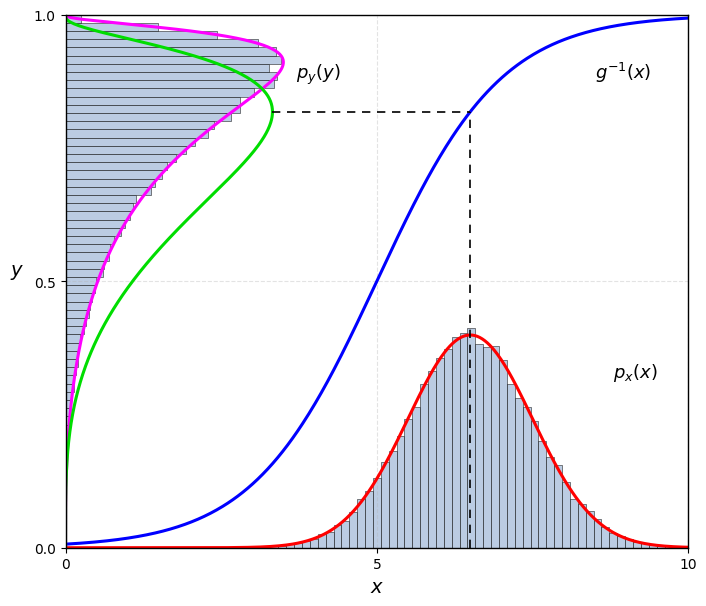

In [3]:
# 教科書 Figure 2.12 の完全再現プロット
fig12, ax12 = plt.subplots(figsize=(7.2, 6.2))

# 1. 50,000 サンプルの生成
x_samples, y_samples = example_1d.sample(N=50000, seed=42)

# 2. x 空間のヒストグラム (薄青色バー)
bins_x = np.linspace(0, 10, 80)
ax12.hist(x_samples, bins=bins_x, density=True, color='#b0c4de', edgecolor='black', lw=0.4, alpha=0.85)

# 3. 元の確率密度 px(x) (赤色曲線)
x_grid = np.linspace(0, 10, 500)
ax12.plot(x_grid, example_1d.px(x_grid), color='red', lw=2.2, label=r'$p_x(x)$')

# 4. 変数変換関数 y = g^{-1}(x) (青色曲線)
ax12.plot(x_grid, example_1d.g_inv(x_grid), color='blue', lw=2.2, label=r'$g^{-1}(x)$')

# 5. y 空間の横向きヒストグラム (薄青色横棒バー)
# y 空間の密度スケールに合わせて横軸長さを調整
scale_y = 1.0
counts_y, bin_edges_y = np.histogram(y_samples, bins=65, range=(0, 1), density=True)
bin_centers_y = 0.5 * (bin_edges_y[:-1] + bin_edges_y[1:])
bin_heights = bin_edges_y[1:] - bin_edges_y[:-1]
for i in range(len(counts_y)):
    ax12.barh(bin_centers_y[i], counts_y[i] * scale_y, height=bin_heights[i], left=0,
              color='#b0c4de', edgecolor='black', lw=0.4, alpha=0.85)

# 6. 真の変換密度 py(y) (マゼンタ色曲線)
y_grid = np.linspace(0.001, 0.999, 600)
py_vals = example_1d.py(y_grid)
ax12.plot(py_vals * scale_y, y_grid, color='magenta', lw=2.2, label=r'$p_y(y)$')

# 7. 単純関数変換 px(g(y)) (緑色曲線)
px_g_vals = example_1d.px_transformed_as_function(y_grid)
scale_green = (np.max(py_vals) * scale_y) / np.max(px_g_vals) * 0.95
ax12.plot(px_g_vals * scale_green, y_grid, color='#00dd00', lw=2.2, label=r'$p_x(g(y))$')

# 8. モードを結ぶ破線
m_x = example_1d.mode_x() # 6.5
m_func_y = example_1d.mode_function_transform() # ~0.818
ax12.plot([m_x, m_x], [0, m_func_y], 'k--', lw=1.2, dashes=(5, 4))
green_peak_x = px_g_vals[np.argmin(np.abs(y_grid - m_func_y))] * scale_green
ax12.plot([green_peak_x, m_x], [m_func_y, m_func_y], 'k--', lw=1.2, dashes=(5, 4))

# 9. 軸・目盛り・枠線の設定
ax12.set_xlim(0, 10)
ax12.set_ylim(0, 1.0)
ax12.set_xticks([0, 5, 10])
ax12.set_yticks([0, 0.5, 1.0])
for spine in ax12.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.0)

ax12.set_xlabel(r'$x$', fontsize=14)
ax12.set_ylabel(r'$y$', fontsize=14, rotation=0, labelpad=12)

# 教科書に準拠した数式テキスト配置
ax12.text(8.8, 0.32, r'$p_x(x)$', fontsize=13, color='black')
ax12.text(8.5, 0.88, r'$g^{-1}(x)$', fontsize=13, color='black')
ax12.text(3.7, 0.88, r'$p_y(y)$', fontsize=13, color='black')

plt.tight_layout()

# 保存
save_plot(fig12, 'result/fig2_12_transformation_of_densities_mode.png')
save_plot(fig12, '../result/fig2_12_transformation_of_densities_mode.png')
plt.show()


<a id="sec_2_4_1"></a>
---
### 2.4.1 多変量分布の密度変換 (Multivariate distributions)

ここまでは1次元確率変数の変換を扱ってきましたが、この原理は $D$ 次元の確率ベクトル空間へと自然に一般化されます。多変量空間での変数変換は、深層生成モデル（Flow-based models）の根幹を成す数学理論です。

#### 1. ベクトル変数の変換と微小体積要素
$D$ 次元の確率ベクトル $\mathbf{x} = (x_1, \dots, x_D)^{\mathrm{T}}$ から $\mathbf{y} = (y_1, \dots, y_D)^{\mathrm{T}}$ への可逆かつ滑らかな変換を考えます：
$$\mathbf{x} = \mathbf{g}(\mathbf{y}) \quad \Longleftrightarrow \quad \mathbf{y} = \mathbf{f}(\mathbf{x})$$

1次元のときと同様、変換の前後で**局所的な確率質量が保存**されなければなりません：
$$p_y(\mathbf{y}) d\mathbf{y} = p_x(\mathbf{x}) d\mathbf{x}$$

多次元空間における微小体積要素 $d\mathbf{x} = dx_1 dx_2 \cdots dx_D$ と $d\mathbf{y} = dy_1 dy_2 \cdots dy_D$ の比率は、多重積分の変数変換定理により、**ヤコビアン行列（ヤコビ行列: Jacobian matrix）の行列式の絶対値** によって与えられます：

$$d\mathbf{x} = |\det \mathbf{J}| d\mathbf{y}$$

ここで、ヤコビアン行列 $\mathbf{J}$ の成分は、逆変換 $\mathbf{x} = \mathbf{g}(\mathbf{y})$ の偏微分として定義されます（**Bishop 2024 式 2.77**）：

$$J_{ij} = \frac{\partial x_i}{\partial y_j} = \frac{\partial g_i}{\partial y_j} \qquad (2.77)$$

したがって、多変量確率密度の変換公式（**Bishop 2024 式 2.76**）が得られます：

$$p_y(\mathbf{y}) = p_x(\mathbf{x}) |\det \mathbf{J}| = p_x(\mathbf{g}(\mathbf{y})) \left| \det \frac{\partial \mathbf{g}}{\partial \mathbf{y}} \right| \qquad (2.76)$$

順方向の写像 $\mathbf{y} = \mathbf{f}(\mathbf{x})$ のヤコビアン $\mathbf{J}_{\mathbf{y}/\mathbf{x}} = \frac{\partial \mathbf{f}}{\partial \mathbf{x}}$ を用いて表す場合は、逆関数の微分則 $\det \mathbf{J}_{\mathbf{x}/\mathbf{y}} = (\det \mathbf{J}_{\mathbf{y}/\mathbf{x}})^{-1}$ より、以下の等価な形となります：

$$p_y(\mathbf{y}) = \frac{p_x(\mathbf{f}^{-1}(\mathbf{y}))}{\left| \det \mathbf{J}_{\mathbf{y}/\mathbf{x}}(\mathbf{f}^{-1}(\mathbf{y})) \right|}$$

---

#### 2. 教科書の具体例 (式 2.78 - 2.79) と Exercise 2.20 の完全解析導出
Bishop & Bishop (2024) では、2次元空間 $\mathbf{x} = (x_1, x_2)^{\mathrm{T}} \to \mathbf{y} = (y_1, y_2)^{\mathrm{T}}$ における極めて興味深い非線形変換が提示されています：

$$y_1 = x_1 + \tanh(5x_1) \qquad (2.78)$$
$$y_2 = x_2 + \tanh(5x_2) + \frac{x_1^3}{3} \qquad (2.79)$$

##### ヤコビアン行列の計算 (Exercise 2.20)
順方向ヤコビアン行列 $\mathbf{J}_{\mathbf{y}/\mathbf{x}} = \begin{pmatrix} \frac{\partial y_1}{\partial x_1} & \frac{\partial y_1}{\partial x_2} \\ \frac{\partial y_2}{\partial x_1} & \frac{\partial y_2}{\partial x_2} \end{pmatrix}$ の各成分を計算します：

1. $\frac{d}{du}\tanh(u) = 1 - \tanh^2(u) = \operatorname{sech}^2(u)$ より：
   $$\frac{\partial y_1}{\partial x_1} = 1 + 5 \operatorname{sech}^2(5x_1)$$
2. $y_1$ は $x_2$ に依存しないため：
   $$\frac{\partial y_1}{\partial x_2} = 0$$
3. $y_2$ の $x_1$ に関する偏微分：
   $$\frac{\partial y_2}{\partial x_1} = \frac{\partial}{\partial x_1}\left(\frac{x_1^3}{3}\right) = x_1^2$$
4. $y_2$ の $x_2$ に関する偏微分：
   $$\frac{\partial y_2}{\partial x_2} = 1 + 5 \operatorname{sech}^2(5x_2)$$

よって、ヤコビアン行列は美しい **下三角行列 (Lower-triangular matrix)** となります：

$$\mathbf{J}_{\mathbf{y}/\mathbf{x}} = \begin{pmatrix} 1 + 5\operatorname{sech}^2(5x_1) & 0 \\ x_1^2 & 1 + 5\operatorname{sech}^2(5x_2) \end{pmatrix}$$

##### ヤコビ行列式の計算
三角行列の行列式は、単に対角成分の積となるため、一瞬で求まります：
$$\det \mathbf{J}_{\mathbf{y}/\mathbf{x}} = \left( 1 + 5\operatorname{sech}^2(5x_1) \right) \left( 1 + 5\operatorname{sech}^2(5x_2) \right)$$

> [!TIP]
> **なぜ単峰ガウス分布が4つのピークに分裂するのか？**
> 原点 $(x_1, x_2) = (0, 0)$ において、$\operatorname{sech}(0) = 1$ であるため：
> $$\det \mathbf{J}(0, 0) = (1 + 5)(1 + 5) = 36$$
> つまり、原点付近の微小面積は $y$ 空間へ写像される際に **36倍に急激に膨張** します！
> 確率密度は体積拡大率の逆数に比例するため、原点での密度は元の密度の $\frac{1}{36}$（約 $2.8\%$）へと激しく低下（抑制）されます。
> 一方、原点から離れた点（$|x_1|, |x_2| \gtrsim 1$）では $\operatorname{sech}(5x) \approx 0$ となり、$\det \mathbf{J} \to 1$ に収束します。
> この「中央部の激しい希薄化」と「外側の保持」、さらに項 $\frac{x_1^3}{3}$ による3次せん断歪み（S字状の曲がり）が合わさることで、**中央の1つの山が4つのローブ（極大値）へと分裂** するのです！


In [4]:
# 2次元非線形写像とヤコビアンの解析計算 (Exercise 2.20) の数値的検証
example_2d = BivariateTransformation2DExample(sigma=0.55)

test_pts = [(0.0, 0.0), (0.5, -0.3), (-1.0, 0.8), (1.2, 1.2)]
h = 1e-6

print("Exercise 2.20 解析ヤコビアン vs 数値有限差分:")
print("-" * 65)
for x1, x2 in test_pts:
    J_ana = example_2d.jacobian_matrix(x1, x2)
    det_ana = example_2d.jacobian_det(x1, x2)
    
    # 有限差分による数値微分
    y1_p, _ = example_2d.forward(x1 + h, x2)
    y1_m, _ = example_2d.forward(x1 - h, x2)
    j11_num = (y1_p - y1_m) / (2 * h)
    
    y1_p2, _ = example_2d.forward(x1, x2 + h)
    y1_m2, _ = example_2d.forward(x1, x2 - h)
    j12_num = (y1_p2 - y1_m2) / (2 * h)
    
    _, y2_p = example_2d.forward(x1 + h, x2)
    _, y2_m = example_2d.forward(x1 - h, x2)
    j21_num = (y2_p - y2_m) / (2 * h)
    
    _, y2_p2 = example_2d.forward(x1, x2 + h)
    _, y2_m2 = example_2d.forward(x1, x2 - h)
    j22_num = (y2_p2 - y2_m2) / (2 * h)
    
    J_num = np.array([[j11_num, j12_num], [j21_num, j22_num]])
    det_num = np.linalg.det(J_num)
    
    print(f"Point ({x1:4.1f}, {x2:4.1f}): det(J_ana)={det_ana:7.3f} | det(J_num)={det_num:7.3f} | J_12={J_ana[0, 1]:.1f}")
    assert np.allclose(J_ana, J_num, rtol=1e-5, atol=1e-5)
    assert abs(det_ana - det_num) < 1e-4

print("-" * 65)
print(f"原点 (0, 0) での体積膨張率: det J(0,0) = {example_2d.jacobian_det(0.0, 0.0):.1f} (理論値: 36.0)")
print("[検証成功] 下三角ヤコビアンおよび行列式の解析式が厳密に成立しています。")


Exercise 2.20 解析ヤコビアン vs 数値有限差分:
-----------------------------------------------------------------
Point ( 0.0,  0.0): det(J_ana)= 36.000 | det(J_num)= 36.000 | J_12=0.0
Point ( 0.5, -0.3): det(J_ana)=  2.157 | det(J_num)=  2.157 | J_12=0.0
Point (-1.0,  0.8): det(J_ana)=  1.008 | det(J_num)=  1.008 | J_12=0.0
Point ( 1.2,  1.2): det(J_ana)=  1.000 | det(J_num)=  1.000 | J_12=0.0
-----------------------------------------------------------------
原点 (0, 0) での体積膨張率: det J(0,0) = 36.0 (理論値: 36.0)
[検証成功] 下三角ヤコビアンおよび行列式の解析式が厳密に成立しています。


<a id="sec_fig2_13"></a>
---
### 教科書図版の完全再現: Figure 2.13

教科書 Bishop & Bishop (2024) p.45 の **Figure 2.13** を完全に再現します。

この図は、単純な2次元等方ガウス分布が、式 (2.78)-(2.79) の非線形変数変換によってどのように変形されるかを、**6枚のパネル（2行3列）** で対比して示しています。

#### パネル構成
- **上段 ($x$ 空間)**:
  1. **左 (Grid)**: 正則な正方格子グリッド（$-1.65 \le x_1, x_2 \le 1.65$）。
  2. **中央 (Density)**: 2次元等方ガウス密度 $p_x(\mathbf{x}) = \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I})$。中央が白・赤・オレンジに光るホットカラーマップ。
  3. **右 (Samples)**: ガウス分布から独立に生成された 600 個のサンプル点群（赤いドット）。
- **中央の矢印 ($\downarrow$)**:
  - $x$ 空間から $y$ 空間への非線形写像 $\mathbf{y} = \mathbf{f}(\mathbf{x})$ を表す下向き矢印。
- **下段 ($y$ 空間)**:
  1. **左 (Deformed Grid)**: 変形した格子グリッド。原点付近の格子間隔が大きく引き伸ばされて中央に空洞ができ、水平線が $x_1^3/3$ の項によって S 字状にせん断されています。
  2. **中央 (Transformed Density)**: 変換後確率密度 $p_y(\mathbf{y})$。ヤコビアンの希薄化により中央が暗く沈み込み、4つの鮮やかなピーク（ローブ）が形成されています。
  3. **右 (Transformed Samples)**: 写像された 600 個のサンプル点群。中央がまばらになり、4つのローブ領域に集中していることが視覚的に確認できます。


/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')


Figure saved successfully to: result/fig2_13_multivariate_transformation.png


Figure saved successfully to: ../result/fig2_13_multivariate_transformation.png


/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


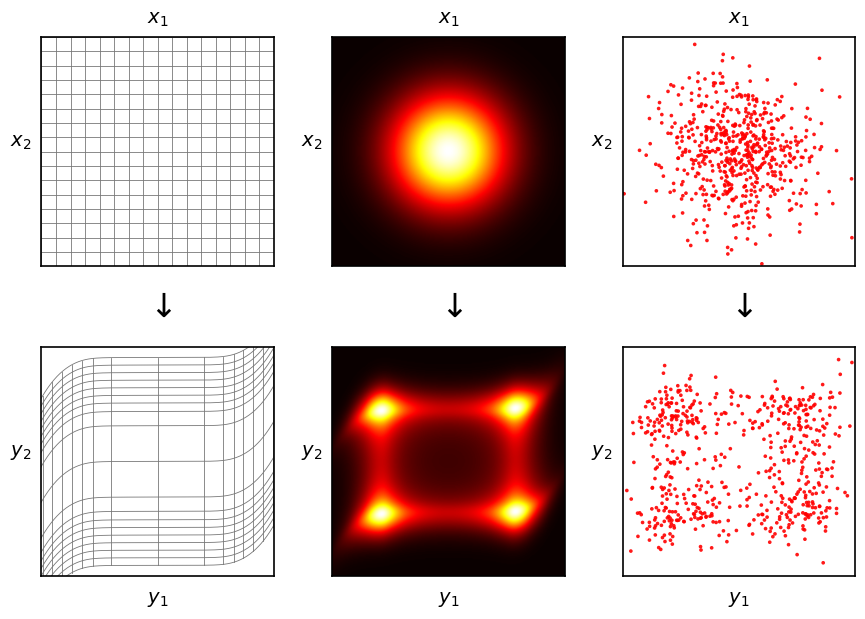

In [5]:
# 教科書 Figure 2.13 の完全再現プロット
x_lim = 1.65
grid_vals = np.linspace(-x_lim, x_lim, 17)
dense_pts = np.linspace(-x_lim, x_lim, 300)

N_pts = 600
x1_s, x2_s, y1_s, y2_s = example_2d.sample(N=N_pts, seed=42)

y1_lim = 2.5
y2_lim = 3.2

fig13 = plt.figure(figsize=(10.5, 7.0))
gs13 = fig13.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.35, wspace=0.25)

# -------------------------------------------------------------
# Row 0, Col 0: Grid in x
# -------------------------------------------------------------
ax00 = fig13.add_subplot(gs13[0, 0])
for v in grid_vals:
    ax00.plot([v, v], [-x_lim, x_lim], color='#777777', lw=0.6)
    ax00.plot([-x_lim, x_lim], [v, v], color='#777777', lw=0.6)
ax00.set_xlim(-x_lim, x_lim)
ax00.set_ylim(-x_lim, x_lim)
ax00.set_xticks([])
ax00.set_yticks([])
for spine in ax00.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)
ax00.set_title(r'$x_1$', fontsize=14, pad=10)
ax00.set_ylabel(r'$x_2$', fontsize=14, rotation=0, labelpad=15)

# -------------------------------------------------------------
# Row 0, Col 1: Density in x
# -------------------------------------------------------------
ax01 = fig13.add_subplot(gs13[0, 1])
x_eval = np.linspace(-x_lim, x_lim, 250)
X1, X2 = np.meshgrid(x_eval, x_eval)
PX = example_2d.px(X1, X2)
ax01.imshow(PX, origin='lower', extent=[-x_lim, x_lim, -x_lim, x_lim], cmap='hot', aspect='auto')
ax01.set_xticks([])
ax01.set_yticks([])
for spine in ax01.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)
ax01.set_title(r'$x_1$', fontsize=14, pad=10)
ax01.set_ylabel(r'$x_2$', fontsize=14, rotation=0, labelpad=15)

# -------------------------------------------------------------
# Row 0, Col 2: Scatter in x
# -------------------------------------------------------------
ax02 = fig13.add_subplot(gs13[0, 2])
ax02.scatter(x1_s, x2_s, s=7, color='red', alpha=0.9, edgecolors='none')
ax02.set_xlim(-x_lim, x_lim)
ax02.set_ylim(-x_lim, x_lim)
ax02.set_xticks([])
ax02.set_yticks([])
for spine in ax02.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)
ax02.set_title(r'$x_1$', fontsize=14, pad=10)
ax02.set_ylabel(r'$x_2$', fontsize=14, rotation=0, labelpad=15)

# -------------------------------------------------------------
# Row 1, Col 0: Grid in y
# -------------------------------------------------------------
ax10 = fig13.add_subplot(gs13[1, 0])
grid_ext = 1.9
grid_vals_ext = np.linspace(-grid_ext, grid_ext, 19)
dense_pts_ext = np.linspace(-grid_ext, grid_ext, 400)
for v in grid_vals_ext:
    y1_c = v + np.tanh(5.0 * v)
    y2_v = dense_pts_ext + np.tanh(5.0 * dense_pts_ext) + (v ** 3) / 3.0
    ax10.plot(np.full_like(dense_pts_ext, y1_c), y2_v, color='#777777', lw=0.6)

    y1_v = dense_pts_ext + np.tanh(5.0 * dense_pts_ext)
    y2_c = v + np.tanh(5.0 * v) + (dense_pts_ext ** 3) / 3.0
    ax10.plot(y1_v, y2_c, color='#777777', lw=0.6)

ax10.set_xlim(-y1_lim, y1_lim)
ax10.set_ylim(-y2_lim, y2_lim)
ax10.set_xticks([])
ax10.set_yticks([])
for spine in ax10.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)
ax10.set_xlabel(r'$y_1$', fontsize=14, labelpad=10)
ax10.set_ylabel(r'$y_2$', fontsize=14, rotation=0, labelpad=15)

# -------------------------------------------------------------
# Row 1, Col 1: Density in y
# -------------------------------------------------------------
ax11 = fig13.add_subplot(gs13[1, 1])
y1_eval = np.linspace(-y1_lim, y1_lim, 220)
y2_eval = np.linspace(-y2_lim, y2_lim, 220)
Y1, Y2 = np.meshgrid(y1_eval, y2_eval)
PY = example_2d.py(Y1, Y2)
ax11.imshow(PY, origin='lower', extent=[-y1_lim, y1_lim, -y2_lim, y2_lim], cmap='hot', aspect='auto')
ax11.set_xticks([])
ax11.set_yticks([])
for spine in ax11.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)
ax11.set_xlabel(r'$y_1$', fontsize=14, labelpad=10)
ax11.set_ylabel(r'$y_2$', fontsize=14, rotation=0, labelpad=15)

# -------------------------------------------------------------
# Row 1, Col 2: Scatter in y
# -------------------------------------------------------------
ax12 = fig13.add_subplot(gs13[1, 2])
ax12.scatter(y1_s, y2_s, s=7, color='red', alpha=0.9, edgecolors='none')
ax12.set_xlim(-y1_lim, y1_lim)
ax12.set_ylim(-y2_lim, y2_lim)
ax12.set_xticks([])
ax12.set_yticks([])
for spine in ax12.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)
ax12.set_xlabel(r'$y_1$', fontsize=14, labelpad=10)
ax12.set_ylabel(r'$y_2$', fontsize=14, rotation=0, labelpad=15)

# -------------------------------------------------------------
# Downward arrows between top and bottom rows
# -------------------------------------------------------------
for ax_top, ax_bot in [(ax00, ax10), (ax01, ax11), (ax02, ax12)]:
    p_top = ax_top.get_position()
    p_bot = ax_bot.get_position()
    xc = 0.5 * (p_top.x0 + p_top.x1)
    yc = 0.5 * (p_top.y0 + p_bot.y1)
    fig13.text(xc, yc, r'$\downarrow$', fontsize=24, ha='center', va='center', weight='bold')

# 保存
save_plot(fig13, 'result/fig2_13_multivariate_transformation.png')
save_plot(fig13, '../result/fig2_13_multivariate_transformation.png')
plt.show()


<a id="sec_deep_learning"></a>
---
### 深層学習との接続: 正規化フロー (Normalizing Flows)

本節で学んだ確率密度の変数変換則（式 2.76）は、現代の生成AI・深層学習において **正規化フロー (Normalizing Flows: 教科書第18章)** と呼ばれる強力な生成モデルファミリーの数理的基礎そのものです。

#### 1. 正規化フローの基本思想
画像や音声などの高次元複雑データ $\mathbf{x} \in \mathbb{R}^D$ の真の確率密度 $p(\mathbf{x})$ を直接モデル化することは極めて困難です。
そこで、扱いやすい単純な基本分布（標準ガウス分布など） $p_0(\mathbf{z}) = \mathcal{N}(\mathbf{z} \mid \mathbf{0}, \mathbf{I})$ を用意し、**可逆なニューラルネットワーク** $f_k$ を $K$ 段連結した合成写像によって複雑なデータ分布を表現します：

$$\mathbf{x} = \mathbf{f}_K \circ \mathbf{f}_{K-1} \circ \cdots \circ \mathbf{f}_1(\mathbf{z})$$

このとき、対数尤度 $\ln p(\mathbf{x})$ は式 (2.76) のチェインルールにより厳密に計算できます：

$$\ln p(\mathbf{x}) = \ln p_0(\mathbf{f}^{-1}(\mathbf{x})) - \sum_{k=1}^K \ln \left| \det \mathbf{J}_{\mathbf{f}_k} \right|$$

#### 2. なぜ三角ヤコビアンが不可欠なのか？
一般の $D \times D$ 正方行列の行列式を計算する計算量は $\mathcal{O}(D^3)$ です。
高解像度画像（例えば $256 \times 256 \times 3 \approx 200,000$ 次元）では、$D^3 \approx 8 \times 10^{15}$ となり、1回の対数尤度評価すら計算不能（爆発）になります。

この問題を打破するのが、本節の **Exercise 2.20 で登場した「下三角ヤコビアン (Lower-triangular Jacobian)」** の構造です！
- 下三角行列であれば、行列式は **対角成分の積** に過ぎません。
- したがって、対数行列式は対角成分の対数和となり、計算量はたったの **$\mathcal{O}(D)$** に激減します！
- **RealNVP**（結合層: Coupling Layer）や **Masked Autoregressive Flows (MAF)**、**Inverse Autoregressive Flows (IAF)**、**Glow** などの代表的な正規化フローモデルは、すべてネットワークの重みや接続を下三角構造にするよう設計されています。

本節で観察した「単純な等方ガウス分布が非線形写像によって4つのローブを持つ複雑な分布へと変貌するメカニズム (Figure 2.13)」こそ、まさに正規化フローがノイズから超高精細な画像を生成するプロセスの最も本質的なミクロの姿なのです。


<a id="sec_summary"></a>
---
### まとめと理解度自己診断

本ノートブックでは、Bishop & Bishop (2024) 第2章 2.4節の全内容を数理・コード・可視化の3方向から徹底的に探究しました。

#### 重要概念の総括
| 項目 | 通常の関数変換 | 確率密度の変数変換 |
| :--- | :--- | :--- |
| **変換公式** | $\tilde{f}(y) = f(g(y))$ | $p_y(y) = p_x(g(y)) \|g'(y)\|$ (1次元)<br>$p_y(\mathbf{y}) = p_x(\mathbf{g}(\mathbf{y})) \|\det \mathbf{J}\|$ (多次元) |
| **本質的要請** | 値の一致 | 局所的な確率質量の保存 ($\int p_y dy = \int p_x dx = 1$) |
| **モード（最大値）の挙動** | 共変保存: $\hat{x} = g(\hat{y})$ | 非線形変換で**シフト**: $\hat{x} \neq g(\hat{y})$ (2階微分項 $g''$ による) |
| **深層学習での応用** | 活性化関数の適用 | 正規化フロー (Normalizing Flows, 第18章) による厳密尤度生成 |

---
#### 理解度セルフチェック
- [ ] 確率密度の変換公式において、なぜ単なる置換ではなく絶対値付き微分係数 $|g'(y)|$（あるいはヤコビ行列式 $|\det \mathbf{J}|$）を掛ける必要があるのか、幾何学的（体積保存）に説明できますか？
- [ ] 式 (2.73) に基づき、非線形変換下で確率密度のモードが移動する理由を数式を用いて説明できますか？また、どのような変換であればモードは保存されますか？
- [ ] 原点 $(0, 0)$ においてヤコビ行列式が 36 となることが、Figure 2.13 の中央部の密度低下と4つのローブの形成にどう寄与しているか説明できますか？
- [ ] 正規化フローモデルにおいて、なぜ三角ヤコビアン行列を持つアーキテクチャが極めて重宝されるのか、計算量の観点（$\mathcal{O}(D^3)$ vs $\mathcal{O}(D)$）から説明できますか？
